In [1]:
# %%capture cap
!pip install -q ipywidgets
!pip install -q autogluon scikit-learn==1.5.2 
!apt-get install -q -y graphviz graphviz-dev && pip install -q pydot
!pip install -q pygraphviz

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.9/44.9 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.5/259.5 kB 9.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 72.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.1/225.1 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.2/64.2 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 454.9/454.9 kB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 487.3/487.3 kB 23.6 MB/s eta 0:00

In [2]:
import torch
import os
import pydot

import random
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from time import time, sleep
from itertools import combinations

from IPython.display import display, Image
import matplotlib.pyplot as plt
import seaborn as sns

import warnings

warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')

## -- Set Global Seed --
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

pd.set_option('display.max_columns', 500)
# plt.style.use("ggplot")
# sns.set_style("whitegrid")

## -- Ansi color codes --
COLOR = '\033[32m'
RESET = '\033[0m'

print("Packages import succesful!")

Packages import succesful!


In [3]:
### Load Data ###
PATH = '/kaggle/input/playground-series-s6e1/'
submit = pd.read_csv(PATH+'sample_submission.csv')
train = pd.read_csv(PATH+"train.csv", index_col='id')
test = pd.read_csv(PATH+"test.csv", index_col='id')

TARGET = train.columns[-1]
NUMS = test.select_dtypes(include='number').columns.tolist()
CATS = test.select_dtypes(exclude='number').columns.tolist()
BASE = NUMS + CATS

ORIG_PATH = '/kaggle/input/exam-score-prediction-dataset/'
orig = pd.read_csv(ORIG_PATH+'Exam_Score_Prediction.csv', index_col='student_id')

for (name, df) in dict(Train=train, Test=test, Original=orig).items():
    print(f"{name} shape: {df.shape}")

print(f"\nTotal Numerical: {len(NUMS)}")
print(f"Total Categorical: {len(CATS)}")
print(f"Total base features: {len(BASE)}")

Train shape: (630000, 12)
Test shape: (270000, 11)
Original shape: (20000, 12)

Total Numerical: 4
Total Categorical: 7
Total base features: 11


In [4]:
display(orig.head())
orig.info()

,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
student_id,,,,,,,,,,,,
1,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9
2,23,other,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate,54.8
3,22,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate,90.3
4,20,other,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate,29.7
5,20,female,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate,43.7


<class 'pandas.core.frame.DataFrame'>
Index: 20000 entries, 1 to 20001
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               20000 non-null  int64  
 1   gender            20000 non-null  object 
 2   course            20000 non-null  object 
 3   study_hours       20000 non-null  float64
 4   class_attendance  20000 non-null  float64
 5   internet_access   20000 non-null  object 
 6   sleep_hours       20000 non-null  float64
 7   sleep_quality     20000 non-null  object 
 8   study_method      20000 non-null  object 
 9   facility_rating   20000 non-null  object 
 10  exam_difficulty   20000 non-null  object 
 11  exam_score        20000 non-null  float64
dtypes: float64(4), int64(1), object(7)
memory usage: 2.0+ MB


In [5]:
MODELS_PATH = "/kaggle/working/AG_models/"
# !rm -r {MODELS_PATH}

In [6]:
from autogluon.tabular import TabularPredictor

In [7]:
TIME_1_HR = 3600
predictor = TabularPredictor(
                label = TARGET,
         # problem_type = "regression",
          # eval_metric = "roc_auc",
                 path = MODELS_PATH,
    ).fit(
                   train_data = orig,
                      presets = "best",
                # num_bag_folds = 8,
                   # auto_stack = False,
             # dynamic_stacking = False,
             # num_stack_levels = 1,
                   time_limit = TIME_1_HR * 2,
                 # num_bag_sets = 2,
                  # ag_args_fit = {'num_cpus': os.cpu_count()},
) 

Preset alias specified: 'best' maps to 'best_quality'.
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.4.0
Python Version:     3.11.13
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Sat Sep 27 10:16:09 UTC 2025
CPU Count:          4
Memory Avail:       29.91 GB / 31.35 GB (95.4%)
Disk Space Avail:   19.50 GB / 19.52 GB (99.9%)
Presets specified: ['best']
Using hyperparameters preset: hyperparameters='zeroshot'
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determine whether the input data is affected by stacked overfitting and enable or disable stacking as a consequence.
	This is used to identify the optimal `num_stack_levels` value. Copies of AutoGluon w

(_ray_fit pid=4365) [1000]	valid_set's rmse: 9.95926
(_ray_fit pid=4504) [1000]	valid_set's rmse: 10.0259 [repeated 2x across cluster]


(_dystack pid=416) 	-9.826	 = Validation score   (-root_mean_squared_error)
(_dystack pid=416) 	18.16s	 = Training   runtime
(_dystack pid=416) 	2.55s	 = Validation runtime
(_dystack pid=416) Fitting model: NeuralNetTorch_r22_BAG_L1 ... Training model for up to 262.56s of the 860.97s of remaining time.
(_dystack pid=416) 	Fitting 8 child models (S1F1 - S1F8) | Fitting with ParallelLocalFoldFittingStrategy (4 workers, per: cpus=1, gpus=0, memory=0.02%)
(_ray_fit pid=4651) 	Ran out of time, stopping training early. (Stopping on epoch 63)
(_dystack pid=416) 	-9.8349	 = Validation score   (-root_mean_squared_error)
(_dystack pid=416) 	180.46s	 = Training   runtime
(_dystack pid=416) 	0.5s	 = Validation runtime
(_dystack pid=416) Fitting model: XGBoost_r33_BAG_L1 ... Training model for up to 77.42s of the 675.84s of remaining time.
(_dystack pid=416) 	Fitting 8 child models (S1F1 - S1F8) | Fitting with ParallelLocalFoldFittingStrategy (4 workers, per: cpus=1, gpus=0, memory=0.15%)
(_dystack

In [8]:
## -- Get Summary -- 
print(f"-> Total models : {len(predictor.model_names())}")
print(f"-> Best model   : {predictor.model_best}\n") 

## -- RUN 1 RESULTS -- 
leaderboard = predictor.leaderboard(silent=True)
leaderboard.style.background_gradient(subset=["score_val"], cmap="Spectral")

-> Total models : 69
-> Best model   : WeightedEnsemble_L2



,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L2,-9.772175,root_mean_squared_error,7.120615,2034.222705,0.001357,0.263451,2,True,69
1,CatBoost_r49_BAG_L1,-9.807019,root_mean_squared_error,0.140650,11.653734,0.140650,11.653734,1,True,51
2,CatBoost_r69_BAG_L1,-9.807089,root_mean_squared_error,0.124620,48.881308,0.124620,48.881308,1,True,33
3,CatBoost_r5_BAG_L1,-9.807730,root_mean_squared_error,0.254860,11.724917,0.254860,11.724917,1,True,67
4,NeuralNetFastAI_r37_BAG_L1,-9.809660,root_mean_squared_error,0.842583,128.196547,0.842583,128.196547,1,True,49
5,LightGBM_r96_BAG_L1,-9.811902,root_mean_squared_error,2.855575,19.841030,2.855575,19.841030,1,True,15
6,CatBoost_r137_BAG_L1,-9.812864,root_mean_squared_error,0.117902,24.018045,0.117902,24.018045,1,True,19
7,CatBoost_BAG_L1,-9.813186,root_mean_squared_error,0.129712,53.671912,0.129712,53.671912,1,True,4
8,NeuralNetFastAI_r145_BAG_L1,-9.815103,root_mean_squared_error,2.391918,258.460391,2.391918,258.460391,1,True,24
9,NeuralNetFastAI_r95_BAG_L1,-9.818485,root_mean_squared_error,1.740710,240.819073,1.740710,240.819073,1,True,43


In [9]:
# ## -- RUN 2: Use original data as extra learning input --
# predictor.fit_pseudolabel(
#                 orig,
#                 use_ensemble = True,
#                 fit_ensemble = True,
#                 time_limit   = 3600*5,
# )

In [10]:
# ## -- Get Summary -- 
# print(f"-> Total models : {len(predictor.model_names())}")
# print(f"-> Best model   : {predictor.model_best}\n") 

# ## -- RUN 2 RESULTS -- 
# leaderboard = predictor.leaderboard(silent=True)
# leaderboard.style.background_gradient(subset=["score_val"], cmap="Spectral")

In [11]:
## -- Create folder directory to save predictions --
SAVE_PATH = '/kaggle/working/AG_preds/'
FILE_NAME = 'ag_student_orig.parquet'
!mkdir {SAVE_PATH}

In [12]:
%%time
## -- Generate predictions --
ag_train_preds = predictor.predict_multi(train.drop([TARGET], axis=1))
ag_test_preds = predictor.predict_multi(test)

## -- Save predictions --
final_train_data = {}
final_test_data = {}

for k, v in tqdm(ag_train_preds.items(), desc='Exporting TRAIN predictions'):
    k_renamed = k.replace('_', '')
    final_train_data[k_renamed] = v

for k, v in tqdm(ag_test_preds.items(), desc='Exporting TEST predictions'):
    k_renamed = k.replace('_', '')
    final_test_data[k_renamed] = v

train_name = f"{SAVE_PATH}train_{FILE_NAME}"
final_train_df = pd.DataFrame(final_train_data)
final_train_df.to_parquet(train_name, index=False)

test_name = f"{SAVE_PATH}test_{FILE_NAME}"
final_test_df = pd.DataFrame(final_test_data)
final_test_df.to_parquet(test_name, index=False)

print(train_name, '&', test_name, 'exported!')

2026-01-11 15:35:13,082	ERROR worker.py:420 -- Unhandled error (suppress with 'RAY_IGNORE_UNHANDLED_ERRORS=1'): The worker died unexpectedly while executing this task. Check python-core-worker-*.log files for more information.
2026-01-11 15:35:13,085	ERROR worker.py:420 -- Unhandled error (suppress with 'RAY_IGNORE_UNHANDLED_ERRORS=1'): The worker died unexpectedly while executing this task. Check python-core-worker-*.log files for more information.
2026-01-11 15:35:13,088	ERROR worker.py:420 -- Unhandled error (suppress with 'RAY_IGNORE_UNHANDLED_ERRORS=1'): The worker died unexpectedly while executing this task. Check python-core-worker-*.log files for more information.


Exporting TRAIN predictions:   0%|          | 0/69 [00:00<?, ?it/s]

Exporting TEST predictions:   0%|          | 0/69 [00:00<?, ?it/s]

/kaggle/working/AG_preds/train_ag_student_orig.parquet & /kaggle/working/AG_preds/test_ag_student_orig.parquet exported!
CPU times: user 5h 38min 12s, sys: 1min 3s, total: 5h 39min 15s
Wall time: 2h 49min


In [13]:
final_train_df.head()

,LightGBMXTBAGL1,LightGBMBAGL1,RandomForestMSEBAGL1,CatBoostBAGL1,ExtraTreesMSEBAGL1,NeuralNetFastAIBAGL1,XGBoostBAGL1,NeuralNetTorchBAGL1,LightGBMLargeBAGL1,CatBoostr177BAGL1,NeuralNetTorchr79BAGL1,LightGBMr131BAGL1,NeuralNetFastAIr191BAGL1,CatBoostr9BAGL1,LightGBMr96BAGL1,NeuralNetTorchr22BAGL1,XGBoostr33BAGL1,ExtraTreesr42BAGL1,CatBoostr137BAGL1,NeuralNetFastAIr102BAGL1,CatBoostr13BAGL1,RandomForestr195BAGL1,LightGBMr188BAGL1,NeuralNetFastAIr145BAGL1,XGBoostr89BAGL1,NeuralNetTorchr30BAGL1,LightGBMr130BAGL1,NeuralNetTorchr86BAGL1,CatBoostr50BAGL1,NeuralNetFastAIr11BAGL1,XGBoostr194BAGL1,ExtraTreesr172BAGL1,CatBoostr69BAGL1,NeuralNetFastAIr103BAGL1,NeuralNetTorchr14BAGL1,LightGBMr161BAGL1,NeuralNetFastAIr143BAGL1,CatBoostr70BAGL1,NeuralNetFastAIr156BAGL1,LightGBMr196BAGL1,RandomForestr39BAGL1,CatBoostr167BAGL1,NeuralNetFastAIr95BAGL1,NeuralNetTorchr41BAGL1,XGBoostr98BAGL1,LightGBMr15BAGL1,NeuralNetTorchr158BAGL1,CatBoostr86BAGL1,NeuralNetFastAIr37BAGL1,NeuralNetTorchr197BAGL1,CatBoostr49BAGL1,ExtraTreesr49BAGL1,LightGBMr143BAGL1,RandomForestr127BAGL1,NeuralNetFastAIr134BAGL1,RandomForestr34BAGL1,LightGBMr94BAGL1,NeuralNetTorchr143BAGL1,CatBoostr128BAGL1,NeuralNetFastAIr111BAGL1,NeuralNetTorchr31BAGL1,ExtraTreesr4BAGL1,NeuralNetFastAIr65BAGL1,NeuralNetFastAIr88BAGL1,LightGBMr30BAGL1,XGBoostr49BAGL1,CatBoostr5BAGL1,NeuralNetTorchr87BAGL1,WeightedEnsembleL2
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,85.849228,87.484894,87.250336,85.963348,85.650665,84.673004,88.859543,86.942528,88.528526,86.035973,86.280724,87.229767,86.014473,87.062050,84.768204,86.008369,85.999321,85.688667,85.564217,85.365067,85.918915,86.196999,85.050369,85.806580,85.434624,86.682762,87.138199,86.820404,85.664490,85.297905,87.340195,86.773010,85.848602,85.149376,86.894615,87.987770,87.070053,86.673767,86.080109,85.251068,87.586472,86.010040,85.801155,86.368408,87.207779,87.357307,86.264442,85.990250,85.108032,86.193558,85.284195,81.320000,88.066048,87.643967,85.500381,88.247124,85.348869,86.616188,87.872169,88.287445,86.377991,87.563950,86.405083,86.989075,85.842255,87.086884,85.302750,85.810791,85.921204
1,66.505585,64.749687,66.686668,66.063919,67.971001,67.616310,64.070618,64.759201,64.886353,65.269135,65.693108,64.905022,66.779175,66.506699,65.921875,66.036240,67.961464,66.400330,66.139572,67.330780,65.676758,65.607330,65.914307,66.680878,64.867851,66.310768,65.341125,64.532379,66.546715,66.235313,66.255295,67.559387,65.971870,66.131531,65.177902,65.300842,68.824577,65.977997,67.815788,64.579987,66.441086,65.981041,66.404190,65.458481,65.205345,64.909187,65.650139,65.986328,66.890915,65.941750,66.051155,64.144997,65.568604,67.059235,67.501122,65.600258,66.206970,65.420013,65.898712,68.375381,66.031013,66.841835,66.491852,67.204926,65.879128,66.210388,66.186081,66.560867,66.088623
2,77.152016,77.363297,77.894333,77.617554,79.403336,77.814629,76.773376,76.272995,77.307190,78.041023,77.191383,77.707016,75.150734,77.413681,77.242363,77.857170,78.734467,78.564003,78.189629,77.362801,77.122749,79.568665,76.010338,76.828003,77.755936,77.634041,78.213394,76.494919,78.057884,77.250107,77.195374,78.045723,77.562027,76.934341,77.951088,77.458092,77.043922,78.219803,76.179695,76.456253,79.690720,77.628494,76.542625,77.902992,77.660988,77.389717,77.733665,78.078102,77.309959,77.273384,77.630028,73.626335,76.830566,77.287498,77.448486,73.268661,77.034470,77.941345,77.365593,76.497261,77.195274,74.784546,77.133232,76.408600,76.912384,77.437607,77.437225,77.144257,77.494308
3,47.320145,45.665417,48.540997,47.070263,50.164330,48.355434,45.969517,49.371891,44.923115,47.545998,48.343510,45.695839,47.346661,46.160694,47.870094,48.362457,46.920448,49.785995,47.144348,47.834000,46.997841,47.196663,48.298454,47.340775,46.954773,47.974075,46.330341,49.564579,46.601273,48.182583,45.276939,48.246254,46.802635,47.334251,48.913696,46.604042,46.588364,45.864216,47.314171,48.184963,47.377205,46.819527,47.953594,48.917252,47.032173,45.631645,47.872234,46

In [14]:
final_test_df.head()

,LightGBMXTBAGL1,LightGBMBAGL1,RandomForestMSEBAGL1,CatBoostBAGL1,ExtraTreesMSEBAGL1,NeuralNetFastAIBAGL1,XGBoostBAGL1,NeuralNetTorchBAGL1,LightGBMLargeBAGL1,CatBoostr177BAGL1,NeuralNetTorchr79BAGL1,LightGBMr131BAGL1,NeuralNetFastAIr191BAGL1,CatBoostr9BAGL1,LightGBMr96BAGL1,NeuralNetTorchr22BAGL1,XGBoostr33BAGL1,ExtraTreesr42BAGL1,CatBoostr137BAGL1,NeuralNetFastAIr102BAGL1,CatBoostr13BAGL1,RandomForestr195BAGL1,LightGBMr188BAGL1,NeuralNetFastAIr145BAGL1,XGBoostr89BAGL1,NeuralNetTorchr30BAGL1,LightGBMr130BAGL1,NeuralNetTorchr86BAGL1,CatBoostr50BAGL1,NeuralNetFastAIr11BAGL1,XGBoostr194BAGL1,ExtraTreesr172BAGL1,CatBoostr69BAGL1,NeuralNetFastAIr103BAGL1,NeuralNetTorchr14BAGL1,LightGBMr161BAGL1,NeuralNetFastAIr143BAGL1,CatBoostr70BAGL1,NeuralNetFastAIr156BAGL1,LightGBMr196BAGL1,RandomForestr39BAGL1,CatBoostr167BAGL1,NeuralNetFastAIr95BAGL1,NeuralNetTorchr41BAGL1,XGBoostr98BAGL1,LightGBMr15BAGL1,NeuralNetTorchr158BAGL1,CatBoostr86BAGL1,NeuralNetFastAIr37BAGL1,NeuralNetTorchr197BAGL1,CatBoostr49BAGL1,ExtraTreesr49BAGL1,LightGBMr143BAGL1,RandomForestr127BAGL1,NeuralNetFastAIr134BAGL1,RandomForestr34BAGL1,LightGBMr94BAGL1,NeuralNetTorchr143BAGL1,CatBoostr128BAGL1,NeuralNetFastAIr111BAGL1,NeuralNetTorchr31BAGL1,ExtraTreesr4BAGL1,NeuralNetFastAIr65BAGL1,NeuralNetFastAIr88BAGL1,LightGBMr30BAGL1,XGBoostr49BAGL1,CatBoostr5BAGL1,NeuralNetTorchr87BAGL1,WeightedEnsembleL2
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
630000,73.288994,72.727737,73.776337,73.354500,73.996002,70.729370,73.325813,72.026711,73.298225,73.646698,71.298630,72.886032,72.818878,73.887650,73.456787,71.449432,73.230904,73.639000,73.545990,71.990852,73.129295,73.048332,73.497765,72.677567,73.428078,72.499008,72.825912,71.295113,73.584679,72.658455,73.533783,74.670563,73.366928,72.372864,71.646416,71.851280,74.409332,73.206039,73.707413,73.482094,73.367920,73.191681,73.047348,71.597351,71.609421,72.978653,72.397049,73.336143,72.567703,72.216705,73.330292,74.005997,73.069809,72.405212,72.310333,72.450317,73.923805,70.444435,73.051720,74.963699,72.256493,75.212143,73.455551,73.332382,73.445686,73.439682,73.353836,71.878632,72.159134
630001,72.205368,69.769440,63.258999,71.176163,68.297333,69.264511,67.088097,67.973160,68.304733,70.110832,68.953499,70.152466,69.288666,71.118187,70.506332,69.261833,66.328209,70.320000,70.557793,69.245117,70.309402,66.528999,72.081551,70.121468,70.057465,69.676727,69.640793,68.307404,70.789398,70.414429,68.229965,68.715958,71.075035,70.721024,69.414345,68.918861,72.381493,71.347214,70.642868,71.098869,65.726662,70.791199,70.542969,68.878784,66.755852,70.072319,69.978271,70.761200,69.586273,69.065956,70.310097,70.064995,68.905266,63.866764,70.612320,67.088074,70.676056,68.401375,71.849823,71.107162,68.384369,68.118515,69.934189,70.276421,72.125404,68.910965,70.160355,69.741898,69.732529
630002,88.660759,88.408424,86.658669,89.643028,87.562332,88.024475,88.418945,89.331604,88.824562,88.926384,89.441887,87.888000,89.099625,89.499763,88.898254,89.690948,88.777222,86.815666,89.332825,88.598717,89.132942,87.157333,88.613571,88.789551,88.721359,89.385078,88.622139,89.987198,89.190834,88.049370,88.167267,87.837929,89.679413,88.946213,87.723480,88.824036,87.707039,88.957565,88.110016,88.459351,87.193031,89.060753,88.573494,90.564415,88.295563,88.616783,89.473557,89.263817,87.882538,88.864143,89.340576,86.750664,89.091522,87.191673,88.596527,86.653137,89.650261,90.281967,89.332787,88.798508,90.141029,87.630302,88.429306,88.249664,88.393143,89.083138,89.053650,90.046104,89.317612
630003,54.722988,55.553127,47.806667,55.089558,50.609329,54.165752,54.208107,53.742805,55.074970,55.456871,54.849251,54.973858,54.721405,54.523304,54.842823,55.003975,52.786076,50.539997,55.539742,54.097290,54.483967,49.111668,54.167645,55.697845,53.889397,54.701916,56.338718,53.297623,54.800987,55.536198,55.009995,51.810326,55.352547,55.488575,53.276543,56.332088,53.890213,54.891781,54.585899,54.419239,48.438953,55.490433,54.786610,55.067131,55.949760,54

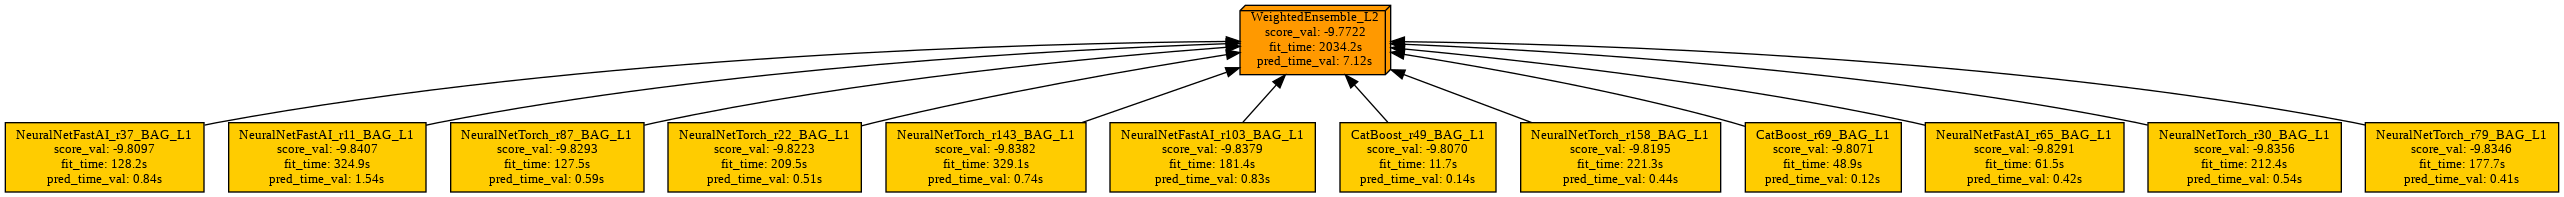

In [15]:
predictor.plot_ensemble_model(filename='ensemble_model.png')
display(Image(f'{MODELS_PATH}ensemble_model.png'))

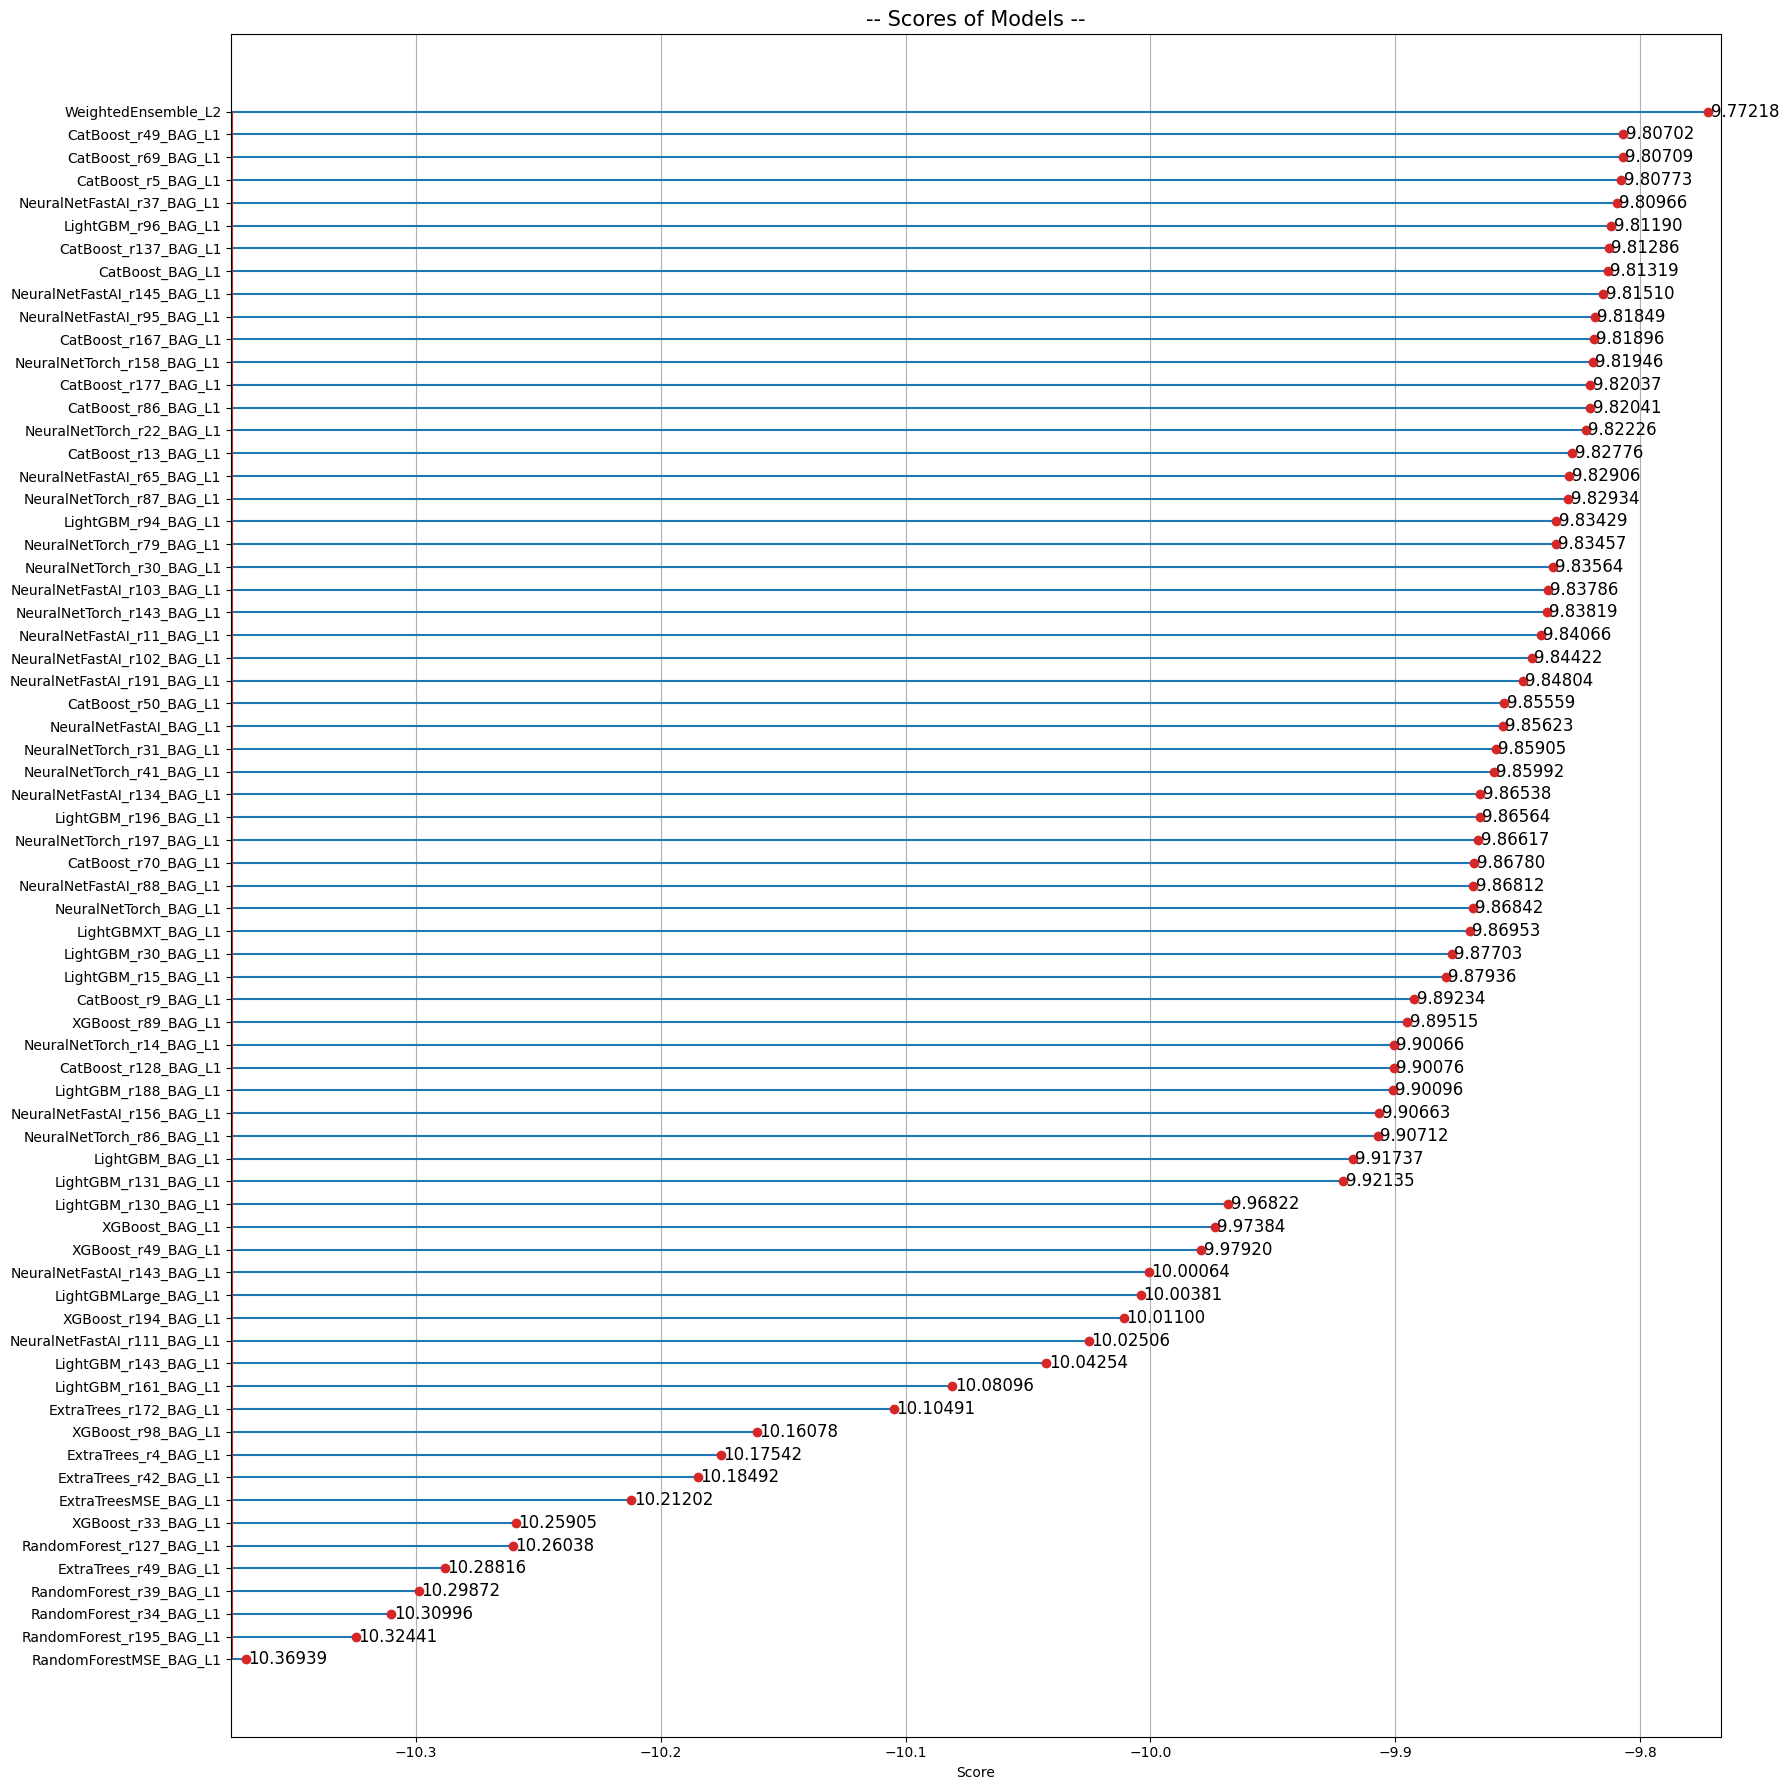

In [16]:
## -- Extract model scores --
result_ = dict(zip(leaderboard['model'], leaderboard['score_val']))
result_df = pd.DataFrame.from_dict(result_, orient='index').sort_values(0)

max_score = result_df.max().item()
min_score = result_df.min().item()

## -- PLOT MODELS & SCORES --
plt.figure(figsize=(18, 18))
plt.stem(
    result_df.index,
    result_df[0],
    orientation = 'horizontal',
    bottom = min_score - 0.0055,
    markerfmt = 'C3o'
)
plt.xlim(min_score - 0.006, max_score + 0.005)
plt.xlabel('Score')
plt.title('-- Scores of Models --', fontsize=15)

for i, value in enumerate(result_df[0]):
    plt.text(value+1e-3, i, f'{abs(value):.5f}', ha='left', va='center', fontdict=dict(size=12))

plt.grid(True, axis='x')
plt.tight_layout()
plt.show()

In [17]:
# predictor.model_names()

In [18]:
# ## -- Permutation Feature Importances --
# feat_imp = predictor.feature_importance(
#                         data = X_test,
#                         # time_limit = 3600,
#                         # model = 'LightGBM_BAG_L1',
#                         # features = None,
#                         # feature_stage = 'transformed',
#                         # subsample_size = 5000,
#                         # num_shuffle_sets = 10,
#                         # include_confidence_band = True,
#                         confidence_level = 0.95,
#                         # silent = False
# ) 

# feat_imp.style.background_gradient(subset=["importance"], cmap="Spectral")

# plt.figure(figsize=(18, 35))
# sns.barplot(data=feat_imp, y=feat_imp.index, x=feat_imp.importance)
# plt.tick_params(axis='y', which='major', labelcolor='r')
# plt.title("Top Features by Permutation")
# plt.tight_layout()
# plt.show()

In [19]:
print(f"""
{'-'*48}
{'█'*5} | - AUTOGLUON NOTEBOOK COMPLETE! - | {'█'*5}
{'-'*48}
""")


------------------------------------------------
█████ | - AUTOGLUON NOTEBOOK COMPLETE! - | █████
------------------------------------------------



In [20]:
## -- OPTIONAL: Delete stored files --
!rm -r {MODELS_PATH}